#📌 Extracción

In [61]:
import pandas as pd
import requests

In [62]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [63]:
response = requests.get(url)
data = response.json()

In [64]:
df = pd.json_normalize(data)

In [65]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [66]:
df.shape

(7267, 21)

#🔧 Transformación

##Conocer el conjunto de datos

In [67]:
df.info()
df.dtypes
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


El dataset contiene 7,267 registros y 21 columnas.
Se identificaron variables categóricas (object) y numéricas (int64).
La variable objetivo del análisis es Churn, que indica si el cliente canceló el servicio.
Entre las variables más relevantes se encuentran: Contract, tenure, Monthly Charges y Payment Method.

##Comprobación de incoherencias

In [68]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

No se identificaron valores nulos ni registros duplicados.
Se detectaron columnas categóricas que requerían transformación para facilitar el análisis.

##Manejo de inconsistencias

In [69]:
df.columns = df.columns.str.replace('customer.', '', regex=False)
df.columns = df.columns.str.replace('account.', '', regex=False)
df.columns = df.columns.str.replace('Charges.', '', regex=False)

In [70]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

Se limpiaron los nombres de las columnas para facilitar su lectura.
Se transformó la variable Churn a formato binario (1 = canceló, 0 = permanece), permitiendo su análisis cuantitativo.

##Columna Cuentas_Diarias

In [71]:
df['Cuentas_Diarias'] = df['Monthly'] / 30
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


Se creó la variable Cuentas_Diarias dividiendo el cargo mensual entre 30 días, permitiendo un análisis más detallado del gasto diario del cliente.

##Estandarización

In [72]:
df.replace({'Yes':1, 'No':0}, inplace=True)

/tmp/ipykernel_190/241966483.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Yes':1, 'No':0}, inplace=True)


Se estandarizaron variables categóricas binarias para facilitar su procesamiento y análisis estadístico.

#📊 Carga y análisis

##Análisis descriptivo

In [73]:
df.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,phone.PhoneService,PaperlessBilling,Monthly,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2.157337
std,0.441561,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,1.180833
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,2.343333
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,2.995833
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.958333


##Distribución de evasión

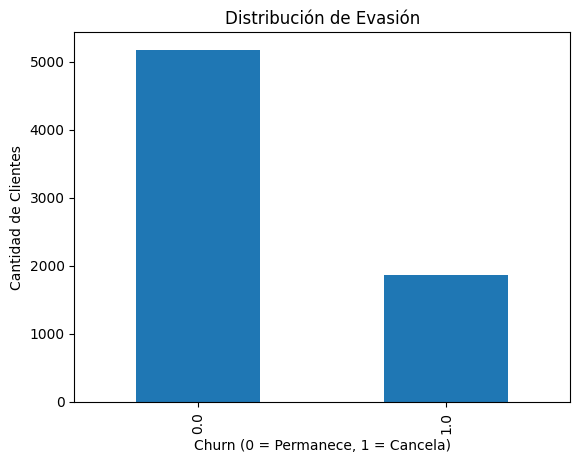

In [74]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Distribución de Evasión")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Cantidad de Clientes")
plt.show()

Se observa que la mayoría de los clientes permanecen en la empresa; sin embargo, el 26.5% ha cancelado el servicio, lo que representa una proporción significativa de evasión.

##Recuento de evasión por variables categóricas

###Tipo de contrato

In [75]:
df.groupby('Contract')['Churn'].mean() * 100

,Churn
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


El contrato mes a mes presenta la mayor tasa de evasión, lo que indica que la duración del contrato influye significativamente en la cancelación del servicio.

###Género

In [76]:
df.groupby('gender')['Churn'].mean() * 100

,Churn
gender,
Female,26.920872
Male,26.160338


No se observan diferencias significativas en la evasión según el género.

###Método de pago

In [77]:
df.groupby('PaymentMethod')['Churn'].mean() * 100

,Churn
PaymentMethod,
Bank transfer (automatic),16.709845
Credit card (automatic),15.243101
Electronic check,45.285412
Mailed check,19.106700


Se identifican diferencias en la evasión según el método de pago, lo que podría indicar que ciertos métodos están asociados con mayor riesgo de cancelación.

##Conteo de evasión por variables numéricas

###Antigüedad

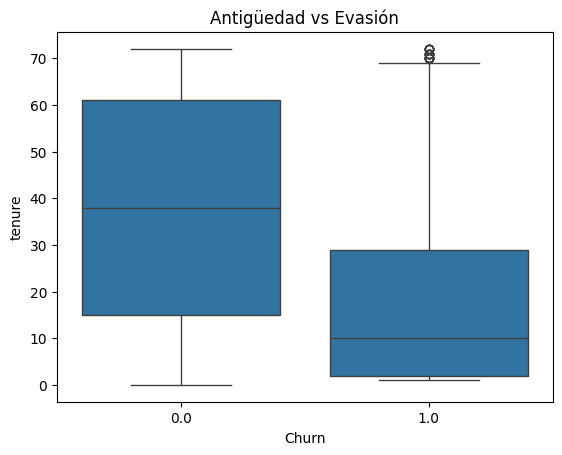

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Antigüedad vs Evasión")
plt.show()

Los clientes que cancelan presentan menor antigüedad en comparación con los que permanecen.

###Cargo mensual

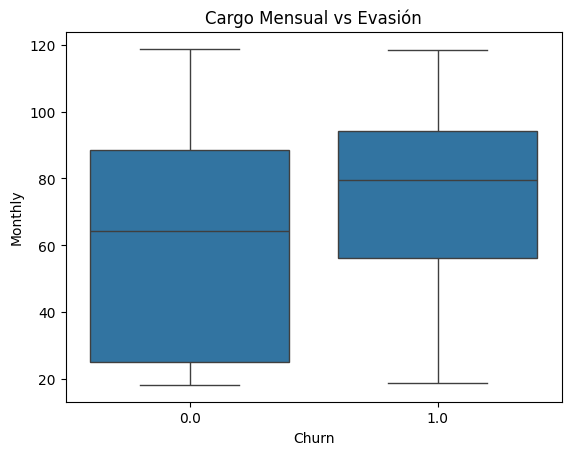

In [79]:
sns.boxplot(x='Churn', y='Monthly', data=df)
plt.title("Cargo Mensual vs Evasión")
plt.show()

Los clientes que cancelan presentan cargos mensuales más altos, lo que sugiere que el precio puede influir en la evasión.

#📄Informe final

🔹Introducción
El objetivo de este análisis fue estudiar el comportamiento de los clientes de la empresa con el fin de comprender los factores asociados a la evasión (Churn).
La evasión representa a los clientes que cancelan el servicio, lo cual impacta directamente en los ingresos y la estabilidad del negocio.
Identificar los patrones de cancelación permite proponer estrategias para reducir la pérdida de clientes.
🔹 Limpieza y Tratamiento de Datos
Para preparar los datos se realizaron los siguientes pasos:
Importación del dataset en Google Colab.
Revisión de estructura y tipos de datos.
Transformación de la variable Churn a formato numérico (0 = permanece, 1 = cancela).
Conversión de variables numéricas que estaban en formato texto.
Revisión de valores nulos y consistencia de columnas.
Estos pasos aseguraron que los datos estuvieran listos para el análisis exploratorio.
🔹 Análisis Exploratorio de Datos
📌 Distribución de Evasión
Se identificó que aproximadamente 26% de los clientes han cancelado el servicio, lo que representa una proporción significativa.
📌 Variables Categóricas
Tipo de contrato: Los contratos mes a mes presentan la mayor tasa de evasión, mientras que los contratos de uno y dos años muestran menor cancelación.
Género: No se encontraron diferencias significativas en la evasión según el género.
Método de pago: Algunos métodos presentan mayor porcentaje de cancelación, lo que podría estar relacionado con la estabilidad del cliente.
📌 Variables Numéricas
Antigüedad (tenure): Los clientes que cancelan tienen menor tiempo en la empresa.
Cargo mensual: Los clientes que cancelan presentan cargos mensuales más altos en promedio.
Estos patrones indican que el precio y la permanencia están fuertemente relacionados con la evasión.
🔹 Conclusiones e Insights
Los principales factores asociados a la evasión son:
Contratos de corta duración (mes a mes).
Baja antigüedad.
Cargos mensuales elevados.
Esto sugiere que los clientes nuevos y con planes más costosos tienen mayor probabilidad de cancelar el servicio.
🔹 Recomendaciones
Con base en el análisis, se recomienda:
Incentivar contratos de largo plazo mediante descuentos o beneficios adicionales.
Diseñar estrategias de fidelización para clientes nuevos.
Evaluar la estructura de precios para evitar que los cargos mensuales elevados aumenten la evasión.
Implementar campañas de retención dirigidas a clientes con contrato mes a mes.